In [162]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, sobel, label, binary_opening, center_of_mass
from scripts.rof import *

1. Take an image and apply Gaussian blur. Plot the image contours for increasing values of σ. What happens? Can you explain why?

In [5]:
im = np.array(Image.open('Resources/bikesgray.jpeg'))

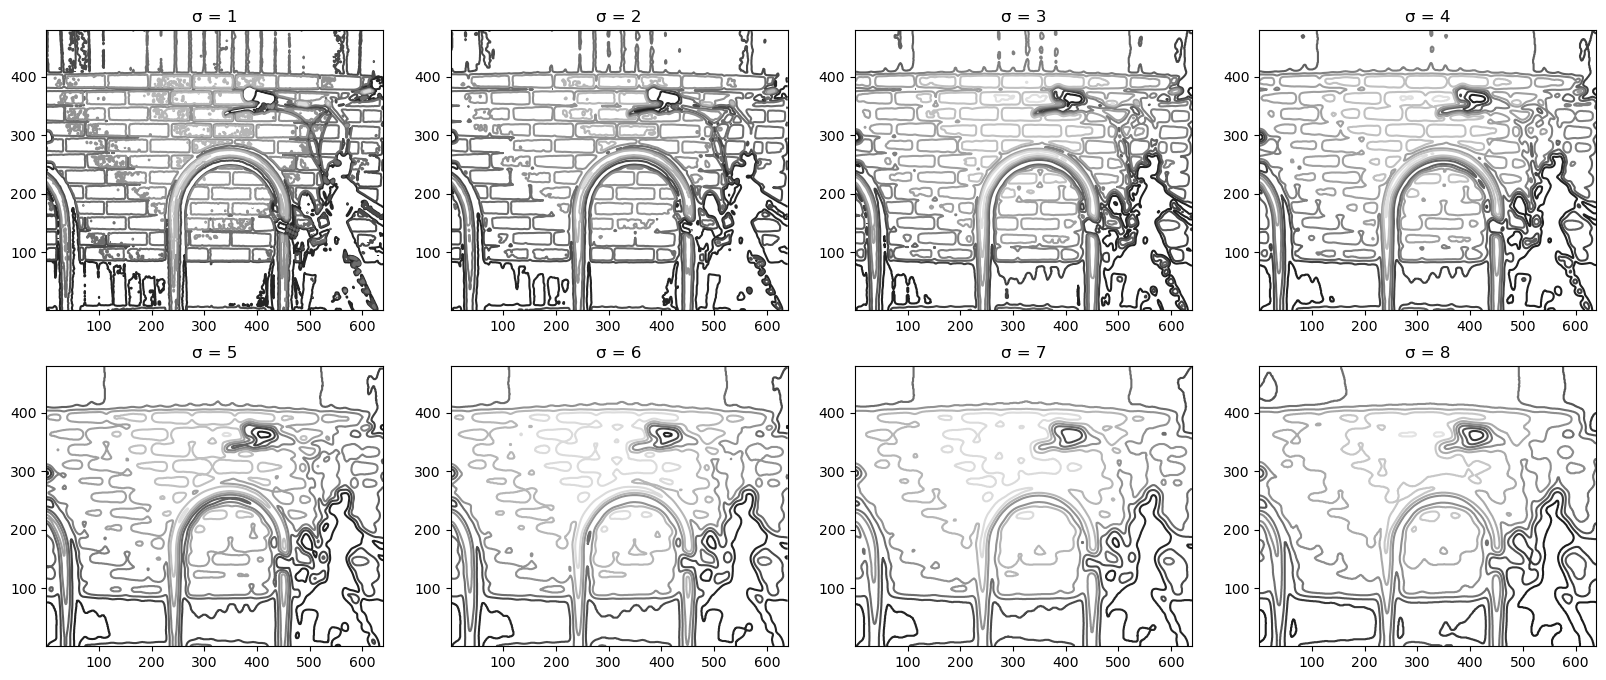

In [6]:
plt.figure(figsize=(20, 8))
plt.gray()

images_number = 8

for i in range(1, images_number + 1):
    ax = plt.subplot(2, int(images_number / 2), i)
    im_blurred = gaussian_filter(im, i)
    plt.contour(im_blurred, origin='image')
    plt.title(f'σ = {i}')
    plt.axis('auto')

plt.show()

As it can be seen, the larger the standard deviation, the more detail of the contours is lost. The more blurred is the image, the more difficult is for the contour function to find contours in the image.

2. Implement an _unsharp masking_ operation (http://en.wikipedia.org/wiki/Unsharp_masking) by blurring an image and then subtracting the blurred version from the original. This gives a sharpening effect of the image. Try this on both color and grayscale images.

In [7]:
pil_im = Image.open('Resources/bird.jpg')
color_im = np.array(pil_im)
grayscale_im = np.array(pil_im.convert('L'))

In [8]:
# grayscale image
# create empty arrays with the same shape as the original image
blurred_grayscale_im = np.zeros(grayscale_im.shape)
sharp_grayscale_im = np.zeros(grayscale_im.shape)

# apply gaussian filter and then unsharp masking
blurred_grayscale_im = gaussian_filter(grayscale_im, 1)
sharp_grayscale_im = grayscale_im + (grayscale_im - blurred_grayscale_im)

# convert the image to 8-bit unsigned integer
sharp_grayscale_im = np.uint8(sharp_grayscale_im)

In [9]:
#color image
# create empty arrays with the same shape as the original image
blurred_color_im = np.zeros(color_im.shape)
sharp_color_im = np.zeros(color_im.shape)

# apply gaussian filter and then unsharp masking for each color channel
for i in range(3):
    blurred_color_im = gaussian_filter(color_im[: ,: , i], 1)
    sharp_color_im[:, :, i] = color_im[:, :, i] + (color_im[: ,: , i] - blurred_color_im)

# convert the image to 8-bit unsigned integer
sharp_color_im = np.uint8(sharp_color_im)

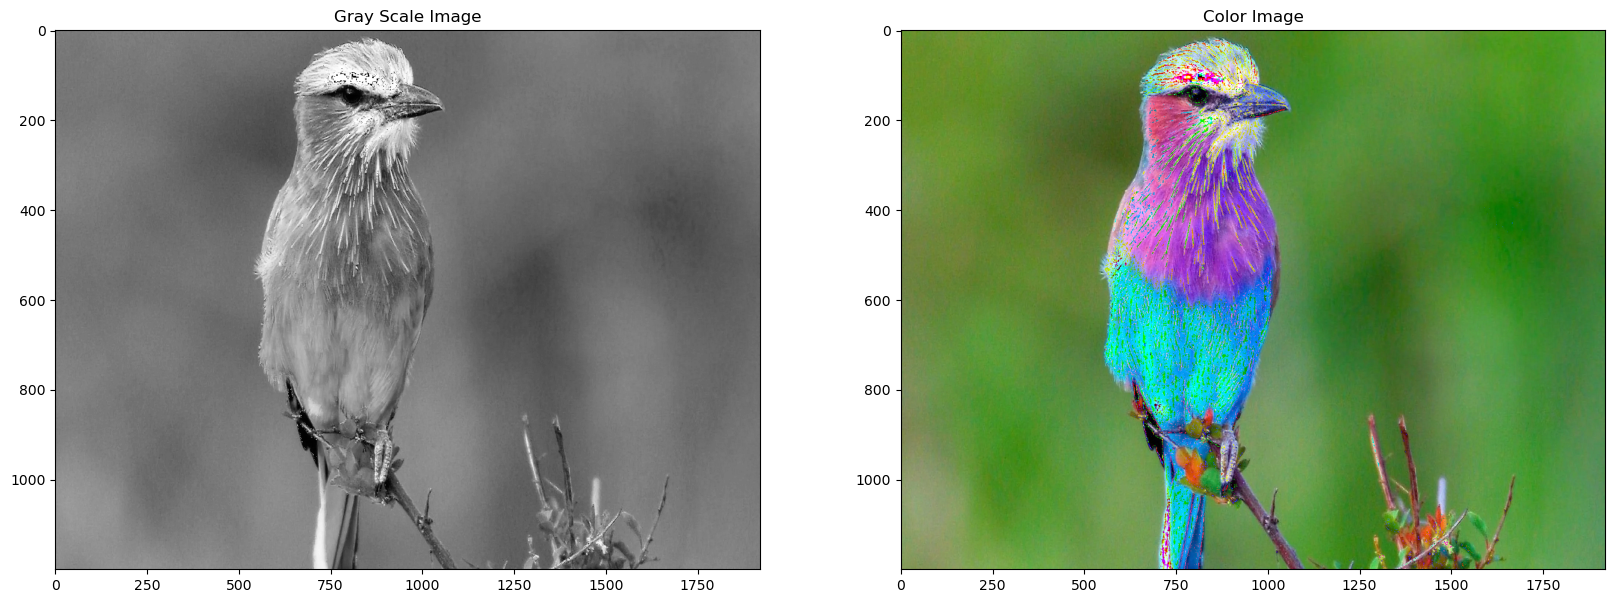

In [10]:
plt.figure(figsize=(20, 7))

ax1 = plt.subplot(121)
plt.imshow(sharp_grayscale_im)
plt.title('Gray Scale Image')
plt.axis('auto')

ax2 = plt.subplot(122)
plt.imshow(sharp_color_im)
plt.title('Color Image')
plt.axis('auto')

plt.show()

3. An alternative image normalization to histogram equalization is a _quotient image_. A quotient image is obtained by dividing the image with a blurred version I/(I * Gσ). Implement this and try it on some sample images.

In [11]:
def quotientImage(original_im, sigma):
    """Image normalization with quotioent image."""

    blurred_im = np.zeros(original_im.shape)
    blurred_im = gaussian_filter(original_im, sigma)

    quotient_im = np.zeros(original_im.shape)
    quotient_im = original_im / blurred_im

    return np.uint8(quotient_im)

In [12]:
im = np.array(Image.open('Resources/bird.jpg').convert('L'))

C:\Users\joel0\AppData\Local\Temp\ipykernel_12140\4210401171.py:8: RuntimeWarning: divide by zero encountered in divide
  quotient_im = original_im / blurred_im
C:\Users\joel0\AppData\Local\Temp\ipykernel_12140\4210401171.py:8: RuntimeWarning: invalid value encountered in divide
  quotient_im = original_im / blurred_im
C:\Users\joel0\AppData\Local\Temp\ipykernel_12140\4210401171.py:10: RuntimeWarning: invalid value encountered in cast
  return np.uint8(quotient_im)


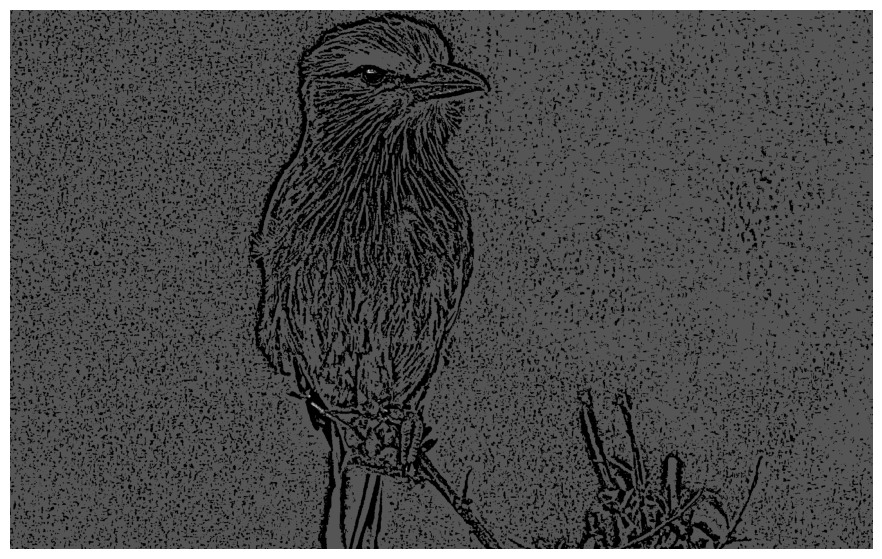

In [13]:
plt.figure(figsize=(15, 7))
plt.imshow(quotientImage(im, 5))
plt.axis('off')
plt.show()

4. Write a function that finds the outline of simple objects in images (for example a square against white backgroud) using image gradients.

In [14]:
def findOutline(im, threshold=100) -> int:
    imx = np.zeros(im.shape)
    sobel(im, 1, imx)

    imy = np.zeros(im.shape)
    sobel(im, 0, imy)

    magnitude = np.sqrt(imx**2 + imy**2)

    magnitude[magnitude > threshold] = 255
    magnitude[magnitude < threshold] = 0

    return magnitude

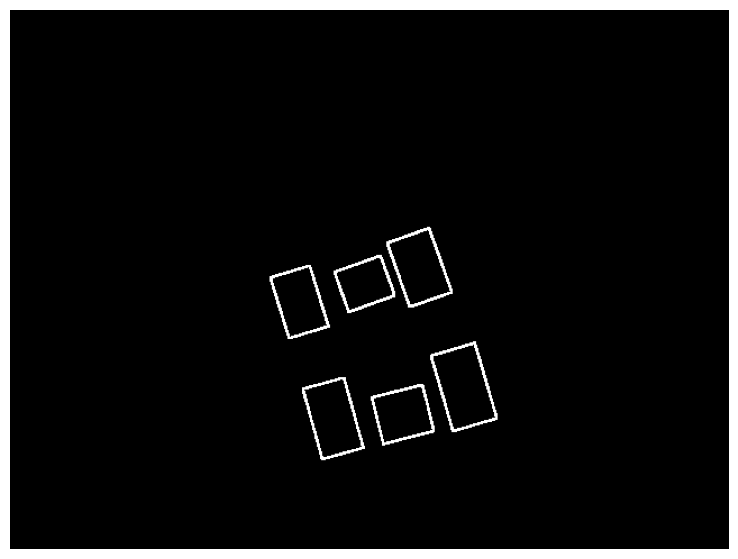

In [15]:
im = np.array(Image.open('Resources/squares.jpg'))

plt.figure(figsize=(15, 7))
plt.imshow(np.uint8(findOutline(im, 200)))
plt.axis('off')
plt.show()

5. Use gradient direction and magnitude to detect lines in an image. Estimate the extent of the lines and their parameters. Plot the lines overlaid on the image.

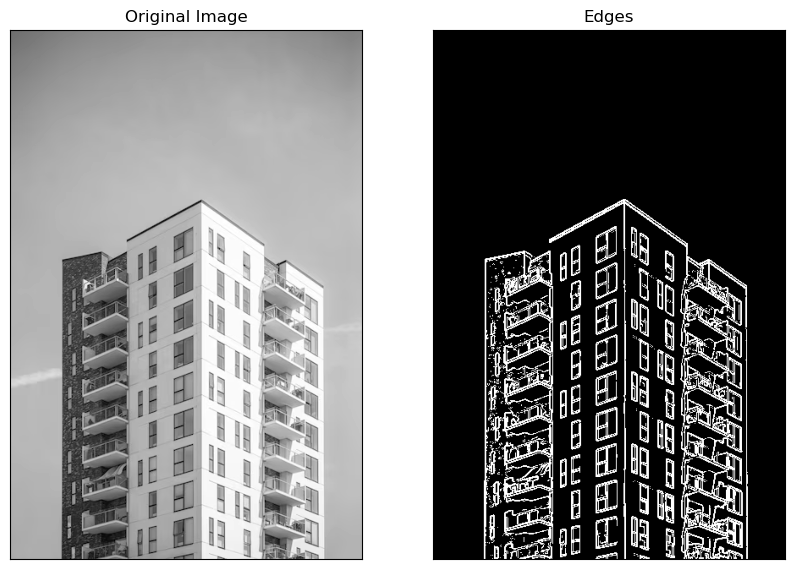

In [124]:
# detect lines with the function of the exercise 4
im = np.array(Image.open('Resources/white_building.png').convert('L'))

plt.figure(figsize=(10, 20))

plt.subplot(2, 2, 1),
plt.imshow(im, cmap='gray')
plt.title('Original Image')
plt.xticks([])
plt.yticks([])

edges = findOutline(im, 150)

plt.subplot(2, 2, 2)
plt.imshow(np.uint8(edges), cmap='gray')
plt.title('Edges')
plt.xticks([])
plt.yticks([])

plt.show()

In [122]:
def hough_transform(im, samples):
    """Hough line transform function. Finds two components to describe a line (r, theta)"""
    heigth, width = im.shape
    max_r = np.sqrt(heigth**2 + width**2)
    accumulator = np.zeros((samples, samples))

    for y in range(heigth):
        for x in range(width):
            if im[y, x] > 0:
                for angle_index in range(samples):
                    theta = (np.pi / 2) * (angle_index / samples) # norm index to [0, 2/pi]rad range
                    r = x * np.cos(theta) + y * np.sin(theta) # r distance
                    r_norm = (r * 255) / max_r # norm r distance to [0, 255] range
                    accumulator[int(r_norm), angle_index] += 1

    return accumulator

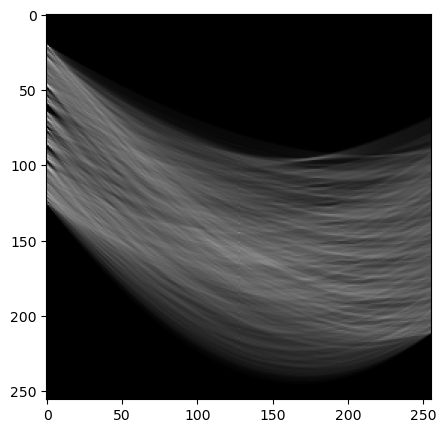

In [141]:
# estimate the extent of the lines and their parameters
samples = 256
accumulator = hough_transform(edges, samples)

plt.figure(figsize=(30, 5))
plt.gray()
plt.imshow(accumulator)
plt.show()

In [142]:
# applies a threshold to take only the most repeated points
threshold = 600
peaks = np.where(accumulator > threshold)

C:\Users\joel0\AppData\Local\Temp\ipykernel_12140\4187390980.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  y0 = r / np.sin(theta)
C:\Users\joel0\AppData\Local\Temp\ipykernel_12140\4187390980.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  y1 = (r - x1 * np.cos(theta)) / np.sin(theta)


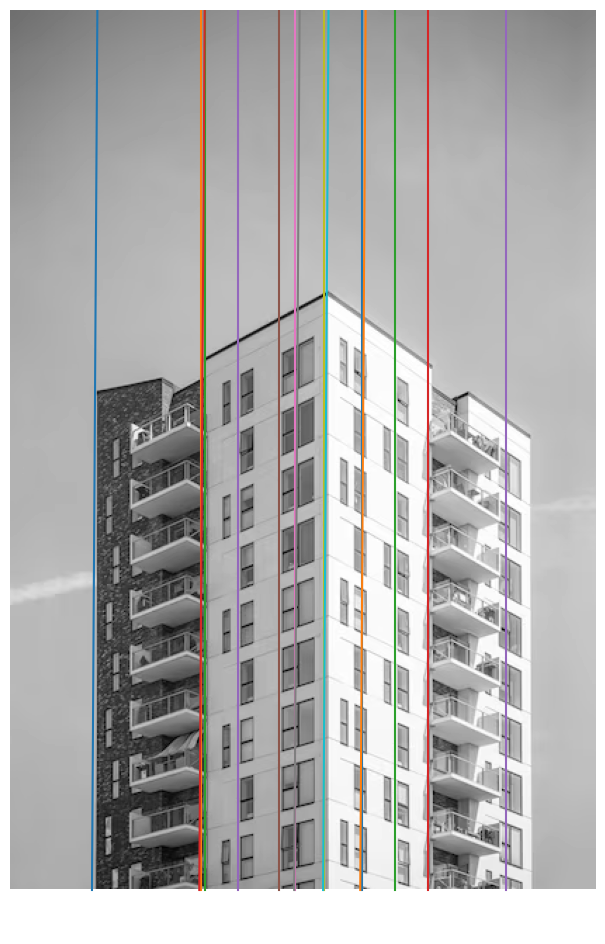

In [145]:
# plot the lines overlaid on the image
plt.figure(figsize=(12, 12))
plt.imshow(im)

for r_max, theta_index in zip(*peaks):
    theta = (np.pi / 2) * (theta_index / 256) # norm theta to the [0..pi/2]rad range
    r = (r_max / samples) * np.sqrt(im.shape[0]**2 + im.shape[1]**2) # norm theta to the [0..samples] range

    x0 = 0
    y0 = r / np.sin(theta)

    if y0 < 0: # avoid exiting the image
        y0 = 0
        x0 = r / np.cos(theta)
    elif y0 >= im.shape[0]:
        y0 = im.shape[0]
        x0 = (r - y0 * np.sin(theta)) / np.cos(theta)

    x1 = im.shape[1]
    y1 = (r - x1 * np.cos(theta)) / np.sin(theta)

    if y1 < 0: # avoid exiting the image
        y1 = 0
        x1 = r / np.cos(theta)
    elif y1 >= im.shape[0]:
        y1 = im.shape[0]
        x1 = (r - y1 * np.sin(theta)) / np.cos(theta)

    plt.plot([x0, x1], [y0, y1])

plt.axis('off')
plt.show()

6. Apply the label() function to a thresholded image of your choice. Use histograms and the resulting label image to plot the distribution of object sizes in the image.

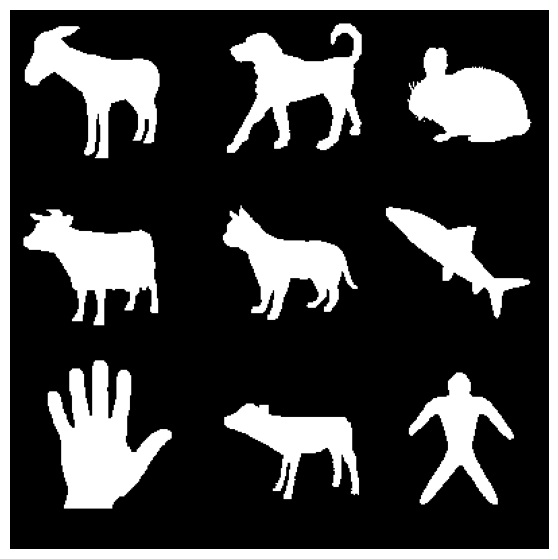

In [155]:
# load image and threshold to make sure it is binary
im = np.array(Image.open('Resources/binary_images.jpg').convert('L'))
im = 1 * (im < 128)

plt.figure(figsize=(7, 7))
plt.imshow(im)
plt.axis('off')
plt.show()

In [150]:
# morphology - opening to separate objects better
im_open = binary_opening(im, np.ones((9, 5)), iterations=2)

labels, nbr_objects = label(im_open)
print(f'Number of objects: {nbr_objects}')

Number of objects: 9


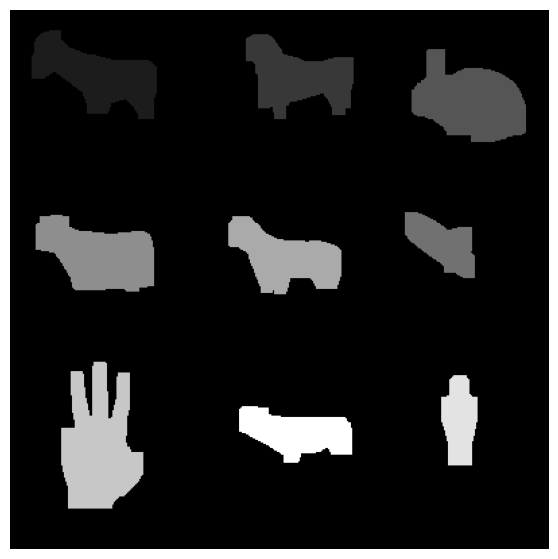

In [156]:
plt.figure(figsize=(7, 7))
plt.imshow(labels)
plt.axis('off')
plt.show()

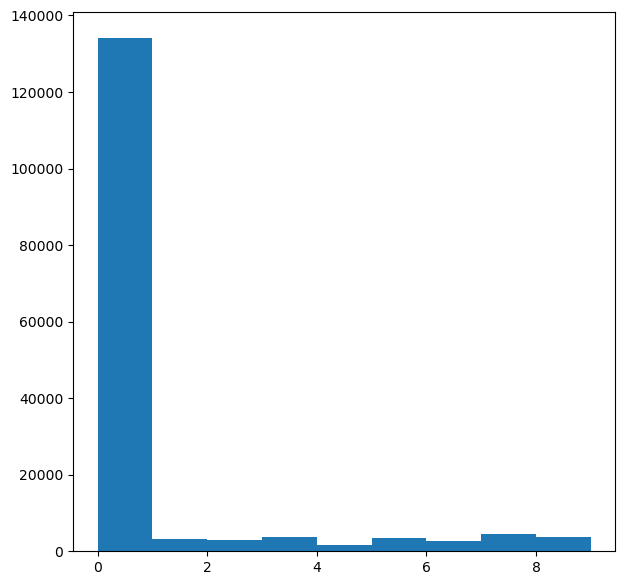

In [159]:
plt.figure(figsize=(7, 7))
plt.hist(labels.flatten(), nbr_objects)
plt.show()

7. Experiment with successive morphological operations on a thresholded image of your choice. When you have found some settings that produce good results, try the function center_of_mass in morphology to find the center coordinates of each object and plot them in the image.

In [195]:
# load image and threshold to make sure it is binary
im = np.array(Image.open('Resources/binary_images.jpg').convert('L'))
im = 1 * (im < 128)

# morphology - opening to separate objects better
im_open = binary_opening(im, np.ones((9, 5)), iterations=2)

labels, nbr_objects = label(im_open)
print(f'Number of objects: {nbr_objects}')

Number of objects: 9


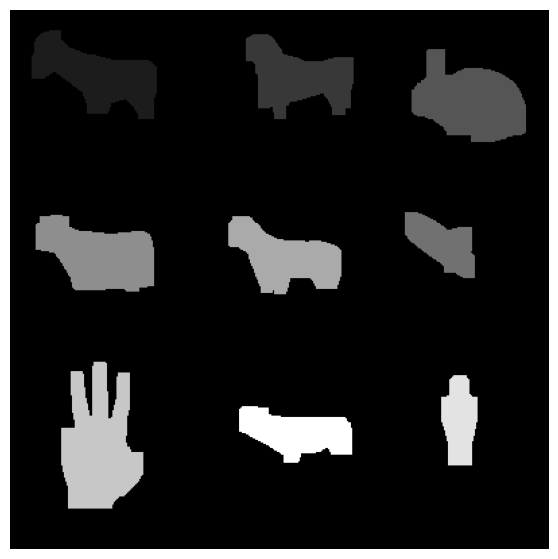

In [196]:
plt.figure(figsize=(7, 7))
plt.imshow(labels)
plt.axis('off')
plt.show()

In [197]:
centers = center_of_mass(im_open, labels, range(nbr_objects))

c:\Users\joel0\anaconda3\Lib\site-packages\scipy\ndimage\_measurements.py:1534: RuntimeWarning: invalid value encountered in divide
  results = [sum(input * grids[dir].astype(float), labels, index) / normalizer


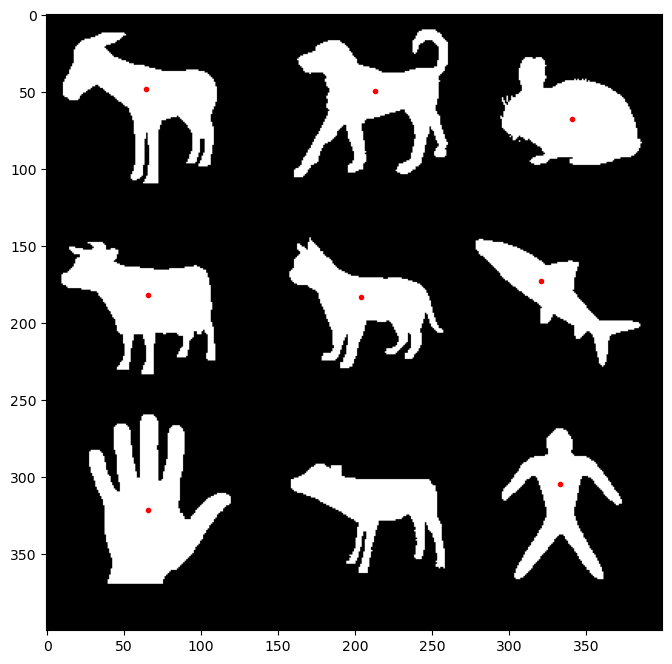

In [198]:
plt.figure(figsize=(8, 8))
plt.imshow(im)
for i in range(nbr_objects):
    plt.plot(centers[i][1], centers[i][0], "r.")
plt.show()